# System 2107: Dataset Alignment Audit
Read-only comparisons of processed inputs. Candidate intervals/shifts exist only in memory; no merged dataset, interpolation, timezone conversion, or input edits.

Coverage uses explicit naive wall-clock grids, with a separate spring-DST adjustment. Completeness requires all 24 AC-power channels; no partial inverter sum is treated as plant power. Wind direction is reported separately from temperature/wind-speed availability.

In [1]:
from pathlib import Path
from itertools import combinations
import json, hashlib, calendar, html
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display, SVG

ROOT = Path.cwd()
if not (ROOT / 'data/2107/processed').is_dir():
    ROOT = ROOT.parent
DATA = ROOT / 'data/2107/processed'
NAMES = ['electrical', 'irradiance', 'environment', 'meter']
paths = {name: DATA / f'2107_{name}_clean.parquet' for name in NAMES}
qc_paths = {name: DATA / f'2107_{name}_qc_events.parquet' for name in ['electrical', 'irradiance', 'meter']}
META = ROOT / 'data/2107/raw/2107_system_metadata.json'

def sha256(path):
    h = hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda: f.read(1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

inputs = list(paths.values()) + list(qc_paths.values()) + [META]
assert all(p.is_file() for p in inputs)
input_hashes = {str(p.relative_to(ROOT)): sha256(p) for p in inputs}
metadata = json.loads(META.read_text(encoding='utf-8'))
schemas = {name: pq.ParquetFile(path).schema_arrow.names for name, path in paths.items()}
power_cols = [c for c in schemas['electrical'] if '_ac_power_' in c]
assert len(power_cols) == 24
# Scan the wide file in batches; retain only the 24 AC-power channels.
power_parts, time_parts = [], []
electrical_missing = pd.Series(0, index=schemas['electrical'][1:], dtype='int64')
for batch in pq.ParquetFile(paths['electrical']).iter_batches(batch_size=50_000):
    part = batch.to_pandas()
    electrical_missing += part.iloc[:, 1:].isna().sum()
    power_parts.append(part[power_cols])
    time_parts.append(part['measured_on'])
raw_e_time = pd.concat(time_parts, ignore_index=True)
e_index = pd.DatetimeIndex(pd.to_datetime(raw_e_time, format='%Y-%m-%d %H:%M:%S', errors='raise'))
power = pd.concat(power_parts, ignore_index=True)
power.index = e_index
del part, batch, power_parts, time_parts
frames = {'electrical': power}
raw_times = {'electrical': raw_e_time}
for name in NAMES[1:]:
    frame = pq.read_table(paths[name]).to_pandas()
    raw_times[name] = frame['measured_on'].copy()
    frame.index = pd.DatetimeIndex(pd.to_datetime(frame.pop('measured_on'), format='%Y-%m-%d %H:%M:%S', errors='raise'))
    frames[name] = frame
indices = {name: frame.index for name, frame in frames.items()}
assert all(i.is_unique and i.is_monotonic_increasing for i in indices.values())
qc = {name: pq.read_table(path).to_pandas() for name, path in qc_paths.items()}
for frame in qc.values():
    frame['time'] = pd.to_datetime(frame['measured_on'], format='%Y-%m-%d %H:%M:%S')
poa_col = frames['irradiance'].columns[0]
poa = frames['irradiance'][poa_col]
meter = frames['meter']['meter_ac_power_kw']
env = frames['environment']
plant = power.sum(axis=1, min_count=24).rename('inverter_ac_kw')
print('Timezone:', metadata['System'].get('timezone_code'), metadata['System'].get('comments'))
display(pd.DataFrame([{ 'column': c, 'units': metadata['Metrics'].get(c, {}).get('units'),
    'aggregation': metadata['Metrics'].get(c, {}).get('aggregation_type')}
    for c in [power_cols[0], poa_col, 'meter_revenue_grade_ac_output_meter_149578']]))

Timezone: PST8PDT Actual timezone is US/Pacific but needed to use special PST8PDT. System is a participant in the DOE Solar Data Prize 2023


,column,units,aggregation
0,inv_01_ac_power_inv_149583,kw,avg
1,poa_irradiance_o_149574,W/m^2,avg
2,meter_revenue_grade_ac_output_meter_149578,kw,avg


## Input summary and overlap
Timestamp coverage and valid-cell availability are different. Nominal coverage below includes naive spring slots; DST-adjusted coverage is reported later. Electrical schema/missingness includes all channels, including the intentionally all-missing inverter 05 DC voltage.

In [2]:
cadence = {'electrical': 5, 'irradiance': 5, 'environment': 15, 'meter': 15}
summary = []
for name, index in indices.items():
    step = pd.Timedelta(minutes=cadence[name])
    expected = int((index[-1] - index[0]) / step) + 1
    diffs = index.to_series().diff().dropna()
    missing = electrical_missing if name == 'electrical' else frames[name].isna().sum()
    summary.append(dict(dataset=name, rows=len(index), first=index[0], last=index[-1],
        nominal_minutes=cadence[name], modal_minutes=diffs.mode().iloc[0].total_seconds()/60,
        naive_expected=expected, timestamp_coverage_pct=100*len(index)/expected,
        missing_cells=int(missing.sum()), rows_complete_for_selected_channels=int(frames[name].notna().all(axis=1).sum())))
    print(name, 'measurement columns:', schemas[name][1:])
    display(missing[missing.gt(0)].rename('missing_cells').to_frame())
input_summary = pd.DataFrame(summary)
display(input_summary)
overlap_rows = []
for label, names in [('electrical + irradiance', NAMES[:2]), ('environment + meter', NAMES[2:]), ('all four', NAMES)]:
    start = max(indices[n][0] for n in names)
    end = min(indices[n][-1] for n in names)
    overlap_rows.append(dict(datasets=label, start=start, end=end, span=end-start))
overlap = pd.DataFrame(overlap_rows)
display(overlap)
common_start, common_end = overlap.iloc[-1][['start', 'end']]

electrical measurement columns: ['inv_01_dc_current_inv_149579', 'inv_01_dc_voltage_inv_149580', 'inv_01_ac_current_inv_149581', 'inv_01_ac_voltage_inv_149582', 'inv_01_ac_power_inv_149583', 'inv_02_dc_current_inv_149584', 'inv_02_dc_voltage_inv_149585', 'inv_02_ac_current_inv_149586', 'inv_02_ac_voltage_inv_149587', 'inv_02_ac_power_inv_149588', 'inv_03_dc_current_inv_149589', 'inv_03_dc_voltage_inv_149590', 'inv_03_ac_current_inv_149591', 'inv_03_ac_voltage_inv_149592', 'inv_03_ac_power_inv_149593', 'inv_04_dc_current_inv_149594', 'inv_04_dc_voltage_inv_149595', 'inv_04_ac_current_inv_149596', 'inv_04_ac_voltage_inv_149597', 'inv_04_ac_power_inv_149598', 'inv_05_dc_current_inv_149599', 'inv_05_dc_voltage_inv_149600', 'inv_05_ac_current_inv_149601', 'inv_05_ac_voltage_inv_149602', 'inv_05_ac_power_inv_149603', 'inv_06_dc_current_inv_149604', 'inv_06_dc_voltage_inv_149605', 'inv_06_ac_current_inv_149606', 'inv_06_ac_voltage_inv_149607', 'inv_06_ac_power_inv_149608', 'inv_07_dc_current_

,missing_cells
inv_01_dc_current_inv_149579,366
inv_01_dc_voltage_inv_149580,366
inv_01_ac_current_inv_149581,366
inv_01_ac_voltage_inv_149582,366
inv_01_ac_power_inv_149583,366
inv_02_dc_current_inv_149584,366
inv_02_dc_voltage_inv_149585,366
inv_02_ac_current_inv_149586,366
inv_02_ac_voltage_inv_149587,366
inv_02_ac_power_inv_149588,366


,missing_cells


,missing_cells
ambient_temperature_c,132
wind_speed_m_s,16
wind_direction_deg,8


,missing_cells


,dataset,rows,first,last,nominal_minutes,modal_minutes,naive_expected,timestamp_coverage_pct,missing_cells,rows_complete_for_selected_channels
0,electrical,632952,2017-11-01 00:00:00,2023-11-07 23:55:00,5,5.0,633024,99.988626,816327,631224
1,irradiance,531019,2017-11-01 07:10:00,2023-11-01 23:55:00,5,5.0,631210,84.127153,0,531019
2,environment,206008,2017-12-01 00:00:00,2023-10-31 23:45:00,15,15.0,207456,99.302021,156,205860
3,meter,240062,2017-01-01 00:15:00,2023-11-09 23:30:00,15,15.0,240382,99.866879,0,240062


,datasets,start,end,span
0,electrical + irradiance,2017-11-01 07:10:00,2023-11-01 23:55:00,2191 days 16:45:00
1,environment + meter,2017-12-01 00:00:00,2023-10-31 23:45:00,2160 days 23:45:00
2,all four,2017-12-01 00:00:00,2023-10-31 23:45:00,2160 days 23:45:00


## Timestamp grids and DST
Transition dates use US Pacific calendar rules for these years, without localizing any measurement. Fall 01:xx is ambiguous even when exported only once. Spring 02:xx omissions are not counted as ordinary loss where the matching transition is observed.

In [3]:
grid_rows = []
for name, index in indices.items():
    seconds = index.hour*3600 + index.minute*60 + index.second
    grid_rows.append(dict(dataset=name, off_nominal_grid=int((seconds % (cadence[name]*60) != 0).sum()),
        quarter_hour_rows=int((seconds % 900 == 0).sum()), seconds_values=sorted(set(index.second)),
        minute_marks=sorted(set(index.minute))))
display(pd.DataFrame(grid_rows))
intersection_rows = []
for a, b in combinations(NAMES, 2):
    intersection_rows.append(dict(datasets=f'{a} + {b}', exact_intersection=len(indices[a].intersection(indices[b]))))
all_intersection = indices[NAMES[0]]
for name in NAMES[1:]:
    all_intersection = all_intersection.intersection(indices[name])
intersection_rows.append(dict(datasets='all four', exact_intersection=len(all_intersection)))
display(pd.DataFrame(intersection_rows))

def sunday(year, month, occurrence):
    first = pd.Timestamp(year=year, month=month, day=1)
    return first + pd.Timedelta(days=(6-first.weekday())%7 + 7*(occurrence-1))

years = range(min(i[0].year for i in indices.values()), max(i[-1].year for i in indices.values())+1)
springs = [sunday(y, 3, 2) for y in years]
falls = [sunday(y, 11, 1) for y in years]
dst_rows = []
for season, days in [('spring', springs), ('fall', falls)]:
    for day in days:
        for name, index in indices.items():
            if day < index[0].normalize() or day > index[-1].normalize():
                continue
            subset = index[(index >= day) & (index < day + pd.Timedelta(days=1))]
            dst_rows.append(dict(season=season, date=day.date(), dataset=name, day_rows=len(subset),
                hour_01=int((subset.hour == 1).sum()), hour_02=int((subset.hour == 2).sum()),
                hour_23=int((subset.hour == 23).sum()), duplicate_local_labels=int(subset.duplicated().sum())))
dst_table = pd.DataFrame(dst_rows)
display(dst_table.pivot(index=['season', 'date'], columns='dataset', values=['day_rows', 'hour_01', 'hour_02', 'hour_23']))
ambiguous_rows = []
for name, index in indices.items():
    affected = pd.DatetimeIndex([])
    for day in falls:
        affected = affected.union(index[(index >= day+pd.Timedelta(hours=1)) & (index < day+pd.Timedelta(hours=2))])
    value = plant if name == 'electrical' else poa if name == 'irradiance' else meter if name == 'meter' else env['ambient_temperature_c']
    vals = value.reindex(affected)
    ambiguous_rows.append(dict(dataset=name, fall_01_rows=len(affected), missing_selected=int(vals.isna().sum()),
        positive_selected=int(vals.gt(0).sum()), maximum_selected=vals.max()))
display(pd.DataFrame(ambiguous_rows))
print('All fall-ambiguous labels lie at 01:xx, outside daytime PV generation; timezone conversion still needs a policy.')

All fall-ambiguous labels lie at 01:xx, outside daytime PV generation; timezone conversion still needs a policy.


,dataset,off_nominal_grid,quarter_hour_rows,seconds_values,minute_marks
0,electrical,0,210984,[0],"[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55]"
1,irradiance,0,177085,[0],"[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55]"
2,environment,0,206008,[0],"[0, 15, 30, 45]"
3,meter,0,240062,[0],"[0, 15, 30, 45]"


,datasets,exact_intersection
0,electrical + irradiance,531019
1,electrical + environment,206008
2,electrical + meter,210692
3,irradiance + environment,175566
4,irradiance + meter,176839
5,environment + meter,205716
6,all four,175320


day_rows                                 hour_01                                 hour_02                                 hour_23                             
dataset           electrical environment irradiance meter electrical environment irradiance meter electrical environment irradiance meter electrical environment irradiance meter
season date                                                                                                                                                                      
fall   2017-11-05      288.0         NaN       76.0  96.0       12.0         NaN        5.0   4.0       12.0         NaN        2.0   4.0       12.0         NaN        0.0   4.0
       2018-11-04      288.0        92.0      288.0  96.0       12.0         4.0       12.0   4.0       12.0         4.0       12.0   4.0       12.0         0.0       12.0   4.0
       2019-11-03      288.0        92.0      288.0  96.0       12.0         4.0       12.0   4.0       12.0         4.0       12.0   4.0       12.0         0.0       12.0   4.0
       2020-11-01      288.0        92.0      240.0  96.0       12.0         4.0       12.0   4.0       12.0         4.0        6.0   4.0       12.0         0.0        8.0   4.0
       2021-11-07      288.0        92.0      236.0  96.0       12.0         4.0        9.0   4.0       12.0         4.0        7.0   4.0       12.0         0.0        5.0   4.0
       2022-11-06      288.0        92.0      229.0  96.0       12.0         4.0       12.0   4.0       12.0         4.0        7.0   4.0       12.0         0.0        4.0   4.0
       2023-11-05      288.0         NaN        NaN  96.0       12.0         NaN        NaN   4.0       12.0         NaN        NaN   4.0       12.0         NaN        NaN   4.0
spring 2017-03-12        NaN         NaN        NaN  92.0        NaN         NaN        NaN   4.0        NaN         NaN        NaN   0.0        NaN         NaN        NaN   4.0
       2018-03-11      276.0        92.0      275.0  92.0       12.0         4.0       12.0   4.0        0.0         0.0        0.0   0.0       12.0         4.0       12.0   4.0
       2019-03-10      276.0        92.0      276.0  92.0       12.0         4.0       12.0   4.0        0.0         0.0        0.0   0.0       12.0         4.0       12.0   4.0
       2020-03-08      276.0        92.0      229.0  92.0       12.0         4.0        7.0   4.0        0.0         0.0        0.0   0.0       12.0         4.0        7.0   4.0
       2021-03-14      276.0        92.0      233.0  92.0       12.0         4.0        7.0   4.0        0.0         0.0        0.0   0.0       12.0         4.0        9.0   4.0
       2022-03-13      276.0        92.0      224.0  92.0       12.0         4.0        5.0   4.0        0.0         0.0        0.0   0.0       12.0         4.0        6.0   4.0
       2023-03-12      276.0        92.0      232.0  92.0       12.0         4.0        7.0   4.0        0.0         0.0        0.0   0.0       12.0         4.0        9.0   4.0

,dataset,fall_01_rows,missing_selected,positive_selected,maximum_selected
0,electrical,84,12,0,0.000000
1,irradiance,62,0,0,0.000000
2,environment,20,0,20,13.222222
3,meter,28,0,0,0.000000


## Gaps and shared missing periods
Gap bounds are the last/next observed timestamps. Long gaps mean more than 24 hours between bounds. Shared missing-slot counts use the common 15-minute grid; these are absent timestamps, not NaN measurements.

In [4]:
gap_rows = []
for name, index in indices.items():
    step = pd.Timedelta(minutes=cadence[name])
    spring_grid = pd.DatetimeIndex([t for d in springs for t in pd.date_range(d+pd.Timedelta(hours=2), d+pd.Timedelta(hours=3)-step, freq=step)])
    delta = index[1:] - index[:-1]
    for j in np.flatnonzero(delta > step):
        left, right = index[j], index[j+1]
        spring_slots = int(spring_grid.searchsorted(right, side='left') - spring_grid.searchsorted(left, side='right'))
        absent = int((right-left)/step)-1
        ordinary = absent-spring_slots
        gap_rows.append(dict(dataset=name, left=left, right=right, duration=right-left,
            missing_slots=absent, spring_slots=spring_slots, ordinary_missing_slots=ordinary, kind='spring DST' if ordinary == 0 and spring_slots else 'long' if right-left > pd.Timedelta(days=1) else 'short'))
gaps = pd.DataFrame(gap_rows)
display(gaps.groupby(['dataset', 'kind']).agg(gaps=('missing_slots','size'), absent_slots=('missing_slots','sum'), spring_slots=('spring_slots','sum'), ordinary_absent=('ordinary_missing_slots','sum'), longest=('duration','max')))
long_gaps = gaps[gaps['kind'].eq('long')].copy()
qgrid = pd.date_range(common_start.ceil('15min'), common_end.floor('15min'), freq='15min')
for name in NAMES:
    long_gaps[f'{name}_missing_quarter_slots'] = [int(((qgrid > r.left) & (qgrid < r.right) & ~qgrid.isin(indices[name])).sum()) for r in long_gaps.itertuples()]
display(long_gaps)
print('Long-gap overlap is compatible with shared acquisition loss, but cannot establish outage cause.')

Long-gap overlap is compatible with shared acquisition loss, but cannot establish outage cause.


gaps  absent_slots  spring_slots  ordinary_absent          longest
dataset     kind                                                                           
electrical  spring DST      6            72            72                0  0 days 01:05:00
environment long            2          1392             0             1392 13 days 02:15:00
            short           8            32             0               32  0 days 01:15:00
            spring DST      6            24            24                0  0 days 01:15:00
irradiance  long            7         18511             0            18511 16 days 22:05:00
            short       36903         81644            36            81608  1 days 00:00:00
            spring DST      3            36            36                0  0 days 01:05:00
meter       long            2           288             0              288  2 days 00:15:00
            short           1             4             0                4  0 days 01:15:00
            spring DST      7            28            28                0  0 days 01:15:00

,dataset,left,right,duration,missing_slots,spring_slots,ordinary_missing_slots,kind,electrical_missing_quarter_slots,irradiance_missing_quarter_slots,environment_missing_quarter_slots,meter_missing_quarter_slots
444,irradiance,2017-12-29 11:20:00,2018-01-08 11:05:00,9 days 23:45:00,2876,0,2876,long,0,959,0,0
446,irradiance,2018-01-08 12:10:00,2018-01-22 12:55:00,14 days 00:45:00,4040,0,4040,long,0,1347,0,0
548,irradiance,2018-04-13 11:30:00,2018-04-23 09:40:00,9 days 22:10:00,2857,0,2857,long,0,952,0,0
17947,irradiance,2021-11-04 07:05:00,2021-11-05 07:15:00,1 days 00:10:00,289,0,289,long,0,96,0,0
21296,irradiance,2022-02-18 13:20:00,2022-03-07 11:25:00,16 days 22:05:00,4872,0,4872,long,0,1624,0,0
23530,irradiance,2022-06-08 00:00:00,2022-06-17 10:10:00,9 days 10:10:00,2713,0,2713,long,0,904,0,0
26658,irradiance,2022-10-23 07:10:00,2022-10-26 07:15:00,3 days 00:05:00,864,0,864,long,0,288,0,0
36924,environment,2020-08-10 21:45:00,2020-08-12 08:00:00,1 days 10:15:00,136,0,136,long,0,30,136,0
36925,environment,2020-10-01 08:45:00,2020-10-14 11:00:00,13 days 02:15:00,1256,0,1256,long,0,219,1256,0
36940,meter,2021-07-15 23:45:00,2021-07-18 00:00:00,2 days 00:15:00,192,0,192,long,0,30,0,192


## Candidate 15-minute intervals
Analysis-only mappings: exact sample; start-labelled `[t,t+15)` samples at t/+5/+10; end-labelled `(t-15,t]` at -10/-5/t. Center-labelled intervals require unprovided sample-support assumptions; bracket with nearby shifts rather than inventing interpolated 2.5-minute boundaries.

A mean is available only when all three samples and all required measurement values exist. Quarter-hour counts use the all-four common range, anchored on the nominal grid (including absent meter/environment labels).

In [5]:
def samples(series, anchors, offsets):
    return pd.DataFrame({offset: series.reindex(anchors+pd.Timedelta(minutes=offset)).to_numpy() for offset in offsets}, index=anchors)

def mean3(series, anchors, offsets):
    block = samples(series, anchors, offsets)
    return block.mean(axis=1).where(block.notna().all(axis=1))

subsample_rows = []
for name, value in [('electrical', plant), ('irradiance', poa)]:
    for label, offsets in [('start', [0,5,10]), ('end', [-10,-5,0])]:
        presence = samples(pd.Series(1, index=indices[name]), qgrid, offsets).notna().sum(axis=1)
        valid = samples(value, qgrid, offsets).notna().sum(axis=1)
        for count in [3,2,1,0]:
            subsample_rows.append(dict(dataset=name, mapping=label, sample_count=count,
                timestamp_periods=int(presence.eq(count).sum()), measurement_complete_periods=int(valid.eq(count).sum())))
display(pd.DataFrame(subsample_rows))
plant_start = mean3(plant, qgrid, [0,5,10])
plant_end = mean3(plant, qgrid, [-10,-5,0])
poa_start = mean3(poa, qgrid, [0,5,10])
poa_end = mean3(poa, qgrid, [-10,-5,0])

,dataset,mapping,sample_count,timestamp_periods,measurement_complete_periods
0,electrical,start,3,207432,207432
1,electrical,start,2,0,0
2,electrical,start,1,0,0
3,electrical,start,0,24,24
4,electrical,end,3,207426,207426
5,electrical,end,2,6,6
6,electrical,end,1,6,6
7,electrical,end,0,18,18
8,irradiance,start,3,155849,155849
9,irradiance,start,2,22231,22231


## Meter interval-label evidence
Positive shift means comparing meter label t to inverter samples beginning at t+shift; inputs are never shifted. Compare both all matched values and an explicitly selected active subset (either power >50 kW). The activity criterion is diagnostic, not cleaning.

Timing sensitivity excludes intervals containing already-flagged electrical suspect events and reviewed meter events, only from the comparison. Report raw errors plus fitted gain errors; gain is diagnostic, not calibration. Yearwise results test stability.

In [6]:
def comparison(x, y, subset):
    pair = pd.concat([x.rename('x'), y.rename('y')], axis=1).dropna()
    if subset == 'active':
        pair = pair[(pair.x > 50) | (pair.y > 50)]
    if len(pair) < 3:
        return dict(n=len(pair), correlation=np.nan, mae_kw=np.nan, rmse_kw=np.nan, gain=np.nan, gain_rmse_kw=np.nan)
    xval, yval = pair.x.to_numpy(), pair.y.to_numpy()
    gain = np.dot(xval,yval)/np.dot(xval,xval) if np.dot(xval,xval) else np.nan
    return dict(n=len(pair), correlation=pair.x.corr(pair.y), mae_kw=float(np.abs(xval-yval).mean()),
        rmse_kw=float(np.sqrt(np.mean((xval-yval)**2))), gain=gain,
        gain_rmse_kw=float(np.sqrt(np.mean((gain*xval-yval)**2))))

meter_anchors = meter.index[(meter.index >= common_start) & (meter.index <= common_end)]
meter_values = meter.reindex(meter_anchors)
e_suspect_times = pd.DatetimeIndex(qc['electrical'].loc[qc['electrical']['flag'].eq('qc_suspect_extreme'), 'time'])
m_flag_times = pd.DatetimeIndex(qc['meter']['time'])
meter_results, yearly_results = [], []
meter_candidates = {}
for mapping, offsets in [('exact', [0]), ('start_mean', [0,5,10]), ('end_mean', [-10,-5,0])]:
    for shift in [-15,-10,-5,0,5,10,15]:
        actual_offsets = [o+shift for o in offsets]
        block = samples(plant, meter_anchors, actual_offsets)
        estimate = block.mean(axis=1).where(block.notna().all(axis=1))
        flagged = pd.Series(meter_anchors.isin(m_flag_times), index=meter_anchors)
        for offset in actual_offsets:
            flagged |= pd.Series((meter_anchors+pd.Timedelta(minutes=offset)).isin(e_suspect_times), index=meter_anchors)
        for sensitivity in ['retained', 'review_flags_excluded']:
            x = estimate if sensitivity == 'retained' else estimate.mask(flagged)
            for subset in ['all', 'active']:
                meter_results.append(dict(mapping=mapping, sample_shift_minutes=shift, sensitivity=sensitivity, subset=subset,
                    **comparison(x,meter_values,subset)))
        if mapping == 'start_mean':
            meter_candidates[shift] = estimate.mask(flagged)
            for year in sorted(set(meter_anchors.year)):
                select = meter_anchors.year == year
                yearly_results.append(dict(year=year, sample_shift_minutes=shift,
                    **comparison(estimate.mask(flagged).loc[select],meter_values.loc[select],'active')))
meter_scores = pd.DataFrame(meter_results)
ranked_meter = meter_scores.query("sensitivity == 'review_flags_excluded' and subset == 'active'").sort_values('gain_rmse_kw')
display(ranked_meter)
display(meter_scores.query("mapping == 'start_mean' and sensitivity == 'retained'"))
yearly_meter = pd.DataFrame(yearly_results)
display(yearly_meter.loc[yearly_meter.groupby('year')['gain_rmse_kw'].idxmin()])
best_meter = ranked_meter.iloc[0]
print('Best active timing candidate:', best_meter[['mapping','sample_shift_minutes','n','correlation','gain_rmse_kw']].to_dict())
print('Start/end means can encode identical sample triples under different shifts; metric ranking alone cannot identify physical interval support.')
# Equal-support sensitivity prevents changing matched samples from driving the ranking.
common_meter = pd.concat(meter_candidates, axis=1)
support = common_meter.notna().all(axis=1) & meter_values.notna()
common_meter_scores = []
for shift in common_meter.columns:
    for subset in ['all', 'meter_active']:
        selected = support & (meter_values.gt(50) if subset == 'meter_active' else True)
        common_meter_scores.append(dict(sample_shift_minutes=shift, equivalent_meter_label_shift_minutes=-shift,
            subset=subset, **comparison(common_meter.loc[selected,shift], meter_values[selected], 'all')))
common_meter_scores = pd.DataFrame(common_meter_scores)
display(common_meter_scores.sort_values(['subset','gain_rmse_kw']))
print('Equal-support active selection uses meter >50 kW, held fixed across all shifts.')

Best active timing candidate: {'mapping': 'start_mean', 'sample_shift_minutes': 0, 'n': 85289, 'correlation': 0.9106826287708583, 'gain_rmse_kw': 87.1192024020246}
Start/end means can encode identical sample triples under different shifts; metric ranking alone cannot identify physical interval support.
Equal-support active selection uses meter >50 kW, held fixed across all shifts.


,mapping,sample_shift_minutes,sensitivity,subset,n,correlation,mae_kw,rmse_kw,gain,gain_rmse_kw
43,start_mean,0,review_flags_excluded,active,85289,0.910683,39.179608,88.641982,0.962377,87.119202
79,end_mean,10,review_flags_excluded,active,85289,0.910683,39.179608,88.641982,0.962377,87.119202
83,end_mean,15,review_flags_excluded,active,85405,0.909675,40.068459,89.244675,0.962032,87.706216
47,start_mean,5,review_flags_excluded,active,85405,0.909675,40.068459,89.244675,0.962032,87.706216
39,start_mean,-5,review_flags_excluded,active,85942,0.902825,47.858389,92.965469,0.960121,91.346232
75,end_mean,5,review_flags_excluded,active,85942,0.902825,47.858389,92.965469,0.960121,91.346232
19,exact,5,review_flags_excluded,active,85295,0.901491,44.534734,94.030538,0.956686,92.111931
51,start_mean,10,review_flags_excluded,active,86019,0.900384,48.832459,94.190752,0.959488,92.542844
23,exact,10,review_flags_excluded,active,85380,0.900471,45.258012,94.622902,0.955962,92.651791
15,exact,0,review_flags_excluded,active,85899,0.891213,52.617884,99.268149,0.953435,97.179831


,mapping,sample_shift_minutes,sensitivity,subset,n,correlation,mae_kw,rmse_kw,gain,gain_rmse_kw
28,start_mean,-15,retained,all,207134,0.954698,28.179140,68.831104,0.952758,67.556190
29,start_mean,-15,retained,active,87042,0.876165,64.631296,105.944090,0.952935,103.988564
32,start_mean,-10,retained,all,207134,0.960271,24.600081,64.483202,0.956448,63.326872
33,start_mean,-10,retained,active,86557,0.889753,56.746854,99.545139,0.956595,97.765548
36,start_mean,-5,retained,all,207134,0.965543,20.603591,60.076820,0.959996,59.029993
37,start_mean,-5,retained,active,85949,0.902597,47.883142,93.080899,0.960125,91.463907
40,start_mean,0,retained,all,207140,0.968935,16.684639,57.062978,0.962265,56.082513
41,start_mean,0,retained,active,85296,0.910448,39.205553,88.764396,0.962379,87.243788
44,start_mean,5,retained,all,207134,0.968473,17.081436,57.485313,0.961925,56.494298
45,start_mean,5,retained,active,85412,0.909442,40.094216,89.366011,0.962034,87.829695


,year,sample_shift_minutes,n,correlation,mae_kw,rmse_kw,gain,gain_rmse_kw
21,2017,0,938,0.766531,65.758904,152.260213,0.990155,152.220613
22,2018,0,14300,0.827045,50.128500,118.046130,0.976501,117.679976
23,2019,0,14455,0.976856,23.840661,46.355605,0.969292,44.409594
24,2020,0,14778,0.963064,35.681389,60.267177,0.938121,53.542362
25,2021,0,14227,0.840495,57.901310,128.786361,0.958977,127.536391
26,2022,0,14022,0.922172,36.929237,83.301328,0.979840,82.818831
27,2023,0,12569,0.976277,27.812087,49.766568,0.954437,45.174073


,sample_shift_minutes,equivalent_meter_label_shift_minutes,subset,n,correlation,mae_kw,rmse_kw,gain,gain_rmse_kw
6,0,0,all,207071,0.969013,16.676434,56.990788,0.962270,56.009248
8,5,-5,all,207071,0.968551,17.072625,57.412762,0.961931,56.420771
4,-5,5,all,207071,0.965620,20.596286,60.008520,0.959997,58.960499
10,10,-10,all,207071,0.964673,21.034313,60.823796,0.959371,59.757176
2,-10,10,all,207071,0.960347,24.593273,64.420097,0.956448,63.262570
12,15,-15,all,207071,0.959130,25.064578,65.392657,0.955677,64.211691
0,-15,15,all,207071,0.954810,28.171310,68.744485,0.952781,67.469140
7,0,0,meter_active,82209,0.908095,37.763525,87.776010,0.964743,86.379858
9,5,-5,meter_active,82209,0.906808,38.660827,88.409523,0.964455,87.000688
5,-5,5,meter_active,82209,0.897857,46.895176,92.557773,0.962617,91.069453


## Environment timestamp evidence
Test complete four-record hours independently by channel. Compare short-lag temperature/wind correlations as a persistence check, not as proof of clock phase. Slowly varying hourly channels cannot establish a one-hour label shift without source documentation or an independent reference.

In [7]:
environment_rows = []
for column in env.columns:
    series = env[column]
    groups = series.groupby(series.index.floor('h'))
    size, valid_count, unique = groups.size(), groups.count(), groups.nunique(dropna=True)
    complete = size.eq(4) & valid_count.eq(4)
    environment_rows.append(dict(channel=column, complete_valid_hours=int(complete.sum()),
        identical_four_values=int((complete & unique.eq(1)).sum()),
        varying_complete_hours=int((complete & unique.gt(1)).sum()),
        changes_on_whole_hours=int(((series.diff().ne(0)) & series.notna() & series.shift().notna() & (series.index.minute==0)).sum()),
        changes_off_whole_hours=int(((series.diff().ne(0)) & series.notna() & series.shift().notna() & (series.index.minute!=0)).sum())))
display(pd.DataFrame(environment_rows))
lag_rows = []
for column in ['ambient_temperature_c','wind_speed_m_s']:
    hourly = env[column][env.index.minute==0]
    for shift in [-60,0,60]:
        other = hourly.reindex(hourly.index + pd.Timedelta(minutes=shift))
        other.index = hourly.index
        lag_rows.append(dict(channel=column, lag_minutes=shift, n=int((hourly.notna() & other.notna()).sum()), correlation=hourly.corr(other)))
display(pd.DataFrame(lag_rows))
print('Four identical quarter-hour values establish exported hourly blocks, not their start/end timing. No evidence here justifies shifting environment timestamps.')

Four identical quarter-hour values establish exported hourly blocks, not their start/end timing. No evidence here justifies shifting environment timestamps.


,channel,complete_valid_hours,identical_four_values,varying_complete_hours,changes_on_whole_hours,changes_off_whole_hours
0,ambient_temperature_c,51469,51469,0,50538,0
1,wind_speed_m_s,51498,51498,0,49294,0
2,wind_direction_deg,51500,51500,0,50236,0


,channel,lag_minutes,n,correlation
0,ambient_temperature_c,-60,51436,0.981180
1,ambient_temperature_c,0,51469,1.000000
2,ambient_temperature_c,60,51436,0.981180
3,wind_speed_m_s,-60,51478,0.929296
4,wind_speed_m_s,0,51498,1.000000
5,wind_speed_m_s,60,51478,0.929296


## Irradiance versus inverter timing
Full common-span 5-minute comparison. Activity means POA >100 W/m? or plant power >50 kW; these are diagnostic selectors. Existing suspect-event times are excluded only for timing sensitivity. Correlation describes synchronization, not a PV model or a quality rule.

In [8]:
ei_start = max(indices['electrical'][0],indices['irradiance'][0])
ei_end = min(indices['electrical'][-1],indices['irradiance'][-1])
ei_anchors = indices['electrical'][(indices['electrical']>=ei_start)&(indices['electrical']<=ei_end)]
xpower = plant.reindex(ei_anchors)
i_flag_times = pd.DatetimeIndex(qc['irradiance']['time'])
irr_results, irr_yearly = [], []
for shift in [-15,-10,-5,0,5,10,15]:
    times = ei_anchors + pd.Timedelta(minutes=shift)
    ypoa = pd.Series(poa.reindex(times).to_numpy(),index=ei_anchors)
    flagged = ei_anchors.isin(e_suspect_times) | times.isin(i_flag_times)
    for sensitivity in ['retained','review_flags_excluded']:
        valid = xpower.notna() & ypoa.notna()
        if sensitivity == 'review_flags_excluded': valid &= ~flagged
        for subset in ['all','active']:
            select = valid & ((ypoa.gt(100)|xpower.gt(50)) if subset=='active' else True)
            irr_results.append(dict(poa_sample_shift_minutes=shift,sensitivity=sensitivity,subset=subset,
                n=int(select.sum()),correlation=xpower[select].corr(ypoa[select])))
    select = xpower.notna() & ypoa.notna() & ~flagged & (ypoa.gt(100)|xpower.gt(50))
    for year in sorted(set(ei_anchors.year)):
        sel = select & (ei_anchors.year==year)
        irr_yearly.append(dict(year=year,poa_sample_shift_minutes=shift,n=int(sel.sum()),correlation=xpower[sel].corr(ypoa[sel])))
irr_scores = pd.DataFrame(irr_results)
display(irr_scores.query("sensitivity == 'review_flags_excluded'").sort_values(['subset','correlation'],ascending=[True,False]))
irr_yearly = pd.DataFrame(irr_yearly)
display(irr_yearly.loc[irr_yearly.groupby('year')['correlation'].idxmax()])
shifted_poa = pd.DataFrame({shift: poa.reindex(ei_anchors+pd.Timedelta(minutes=shift)).to_numpy()
    for shift in [-15,-10,-5,0,5,10,15]}, index=ei_anchors)
shared = shifted_poa.notna().all(axis=1) & xpower.notna() & ~ei_anchors.isin(e_suspect_times)
for shift in shifted_poa.columns:
    shared &= ~(ei_anchors+pd.Timedelta(minutes=shift)).isin(i_flag_times)
common_irr_scores=[]
for shift in shifted_poa.columns:
    for subset in ['all','plant_active']:
        select=shared & (xpower.gt(50) if subset=='plant_active' else True)
        common_irr_scores.append(dict(poa_sample_shift_minutes=shift,subset=subset,n=int(select.sum()),
            correlation=xpower[select].corr(shifted_poa.loc[select,shift])))
common_irr_scores=pd.DataFrame(common_irr_scores)
display(common_irr_scores.sort_values(['subset','correlation'],ascending=[True,False]))
print('Equal-support active selection uses plant >50 kW, held fixed across shifts.')

Equal-support active selection uses plant >50 kW, held fixed across shifts.


,poa_sample_shift_minutes,sensitivity,subset,n,correlation
15,0,review_flags_excluded,active,249846,0.878520
19,5,review_flags_excluded,active,249556,0.850067
23,10,review_flags_excluded,active,249636,0.840646
11,-5,review_flags_excluded,active,251483,0.838113
27,15,review_flags_excluded,active,249943,0.834161
7,-10,review_flags_excluded,active,253262,0.819627
3,-15,review_flags_excluded,active,255072,0.804402
14,0,review_flags_excluded,all,530924,0.954534
18,5,review_flags_excluded,all,530920,0.944135
22,10,review_flags_excluded,all,530914,0.940593


,year,poa_sample_shift_minutes,n,correlation
21,2017,0,803,0.249035
22,2018,0,39524,0.820089
23,2019,0,43302,0.956967
24,2020,0,44428,0.965627
25,2021,0,43233,0.730969
26,2022,0,40673,0.926568
27,2023,0,37883,0.948840


,poa_sample_shift_minutes,subset,n,correlation
6,0,all,424075,0.952078
8,5,all,424075,0.940110
10,10,all,424075,0.935997
4,-5,all,424075,0.933216
12,15,all,424075,0.932949
2,-10,all,424075,0.923349
0,-15,all,424075,0.914716
7,0,plant_active,240782,0.946926
9,5,plant_active,240782,0.916842
11,10,plant_active,240782,0.906438


## Cross-dataset QC context
Exact timestamp values stay separate from nearby quarter-hour values. The nearby meter row is a diagnostic reference, not an aligned measurement. Missing inverter channels make the strict plant total unavailable; the observed partial sum is explicitly labeled.

In [9]:
expected_flags = {'electrical': {'qc_corrupt':3,'qc_suspect_extreme':4},
    'irradiance': {'qc_suspect_ceiling':11,'qc_suspect_night':77,'qc_suspect_spike':3},
    'meter': {'qc_suspect_night':135,'qc_suspect_spike':1,'qc_suspect_daytime_zero':2}}
for name, counts in expected_flags.items():
    assert qc[name]['flag'].value_counts().to_dict() == counts
context_rows = []
for name, events in qc.items():
    for event in events.itertuples():
        t = event.time
        powers = power.reindex([t]).iloc[0]
        near = meter.index.get_indexer([t],method='nearest',tolerance=pd.Timedelta(minutes=7.5))[0]
        near_time = meter.index[near] if near>=0 else pd.NaT
        context_rows.append(dict(dataset=name,flag=event.flag,time=t,raw_value=event.raw_value,
            plant_kw=plant.get(t,np.nan),observed_partial_kw=powers.sum(min_count=1),reporting_inverters=int(powers.notna().sum()),
            poa=poa.get(t,np.nan),meter_exact_kw=meter.get(t,np.nan),meter_near_time=near_time,
            meter_near_kw=meter.iloc[near] if near>=0 else np.nan,
            temperature_c=env['ambient_temperature_c'].get(t,np.nan)))
qc_context = pd.DataFrame(context_rows)
display(qc_context.groupby(['dataset','flag']).agg(events=('time','size'),
    strict_plant_available=('plant_kw','count'),partial_plant_available=('observed_partial_kw','count'),
    plant_min=('plant_kw','min'),plant_max=('plant_kw','max'),poa_available=('poa','count'),
    poa_min=('poa','min'),poa_max=('poa','max'),meter_exact_available=('meter_exact_kw','count'),
    meter_min=('meter_exact_kw','min'),meter_max=('meter_exact_kw','max')))
display(qc_context.loc[~qc_context['flag'].eq('qc_suspect_night')])
# Read only event channels and peer inverter channels for exact local electrical context.
event_columns=sorted(set(qc['electrical']['raw_column']))
event_channels=pq.read_table(paths['electrical'],columns=['measured_on']+event_columns).to_pandas()
event_channels.index=pd.to_datetime(event_channels.pop('measured_on'))
e_details=[]
for event in qc['electrical'].itertuples():
    t=event.time
    v=event_channels[event.raw_column]
    peer_cols=[c for c in schemas['electrical'][1:] if f'_{event.measurement}_' in c]
    peer=pq.read_table(paths['electrical'],columns=['measured_on']+peer_cols,
        filters=[('measured_on','=',event.measured_on)]).to_pandas()
    peer_values=peer[peer_cols].iloc[0].dropna().to_numpy() if len(peer) else np.array([])
    peer_values=peer_values[peer_values != v.get(t,np.nan)] if pd.notna(v.get(t,np.nan)) else peer_values
    e_details.append(dict(time=t,inverter=event.inverter,measurement=event.measurement,flag=event.flag,
        raw=event.raw_value,processed=v.get(t,np.nan),before=v.get(t-pd.Timedelta(minutes=5),np.nan),
        after=v.get(t+pd.Timedelta(minutes=5),np.nan),peer_min=np.min(peer_values) if len(peer_values) else np.nan,
        peer_max=np.max(peer_values) if len(peer_values) else np.nan))
display(pd.DataFrame(e_details))
for t in qc['meter'].loc[qc['meter']['flag'].eq('qc_suspect_spike'),'time']:
    window=pd.date_range(t-pd.Timedelta(minutes=30),t+pd.Timedelta(minutes=30),freq='5min')
    display(pd.DataFrame({'plant_kw':plant.reindex(window),'poa':poa.reindex(window),'meter_kw':meter.reindex(window)}))
irr_detail=[]
for event in qc['irradiance'].loc[~qc['irradiance']['flag'].eq('qc_suspect_night')].itertuples():
    t=event.time
    irr_detail.append(dict(time=t,flag=event.flag,poa=poa.get(t,np.nan),
        poa_before=poa.get(t-pd.Timedelta(minutes=5),np.nan),poa_after=poa.get(t+pd.Timedelta(minutes=5),np.nan),
        power=plant.get(t,np.nan),power_before=plant.get(t-pd.Timedelta(minutes=5),np.nan),power_after=plant.get(t+pd.Timedelta(minutes=5),np.nan)))
display(pd.DataFrame(irr_detail))
for source in ['irradiance','meter']:
    night_context=qc_context[(qc_context.dataset==source)&qc_context.flag.eq('qc_suspect_night')]
    groups=night_context.time.dt.date if source=='irradiance' else night_context.time.dt.year
    display(night_context.groupby(groups).agg(events=('time','size'),
        power_available=('plant_kw','count'),power_min=('plant_kw','min'),power_max=('plant_kw','max'),
        poa_available=('poa','count'),poa_min=('poa','min'),poa_max=('poa','max'),meter_min=('meter_exact_kw','min'),meter_max=('meter_exact_kw','max')))
# Review the longest POA gap against present-but-zero meter/electrical records.
longest_poa = long_gaps[long_gaps.dataset.eq('irradiance')].sort_values('duration').iloc[-1]
zero_window = qgrid[(qgrid>longest_poa.left)&(qgrid<longest_poa.right)]
display(pd.DataFrame([dict(start=longest_poa.left,end=longest_poa.right,quarter_slots=len(zero_window),
    meter_present=int(meter.reindex(zero_window).notna().sum()),meter_zero=int(meter.reindex(zero_window).eq(0).sum()),
    plant_present=int(plant.reindex(zero_window).notna().sum()),plant_zero=int(plant.reindex(zero_window).eq(0).sum()))]))
print('QC records are read-only; context does not change labels or authorize replacements.')

QC records are read-only; context does not change labels or authorize replacements.


events  strict_plant_available  partial_plant_available  plant_min  plant_max  poa_available  poa_min  poa_max  meter_exact_available  meter_min  meter_max
dataset    flag                                                                                                                                                                                
electrical qc_corrupt                    3                       3                        3    319.637    688.841              3    570.2    779.3                      2   304.6400     495.36
           qc_suspect_extreme            4                       4                        4    414.310    690.814              4    463.9   1013.6                      3   323.8400     555.52
irradiance qc_suspect_ceiling           11                      11                       11    545.671    709.662             11   1400.0   1400.0                      1   488.9600     488.96
           qc_suspect_night             77                      77                       77      0.000      0.000             77    713.2    768.9                     25     0.0000       0.00
           qc_suspect_spike              3                       3                        3    543.658    684.216              3   1223.2   1390.6                      0        NaN        NaN
meter      qc_suspect_daytime_zero       2                       2                        2      0.000    686.787              2    975.9    984.5                      2     0.0000       0.00
           qc_suspect_night            135                      48                       49      0.000      0.000             29      0.0      0.0                    135     0.0064       0.64
           qc_suspect_spike              1                       1                        1    687.612    687.612              1    986.2    986.2                      1  1783.6800    1783.68

,dataset,flag,time,raw_value,plant_kw,observed_partial_kw,reporting_inverters,poa,meter_exact_kw,meter_near_time,meter_near_kw,temperature_c
0,electrical,qc_corrupt,2018-08-01 16:00:00,4.560000e+10,342.659,342.659,24,634.1,304.64,2018-08-01 16:00:00,304.64,29.833333
1,electrical,qc_corrupt,2018-08-07 14:40:00,9.350000e+10,319.637,319.637,24,570.2,NaN,2018-08-07 14:45:00,252.80,NaN
2,electrical,qc_corrupt,2019-06-20 10:45:00,1.380000e+12,688.841,688.841,24,779.3,495.36,2019-06-20 10:45:00,495.36,24.555556
3,electrical,qc_suspect_extreme,2019-06-20 10:45:00,1.053410e+02,688.841,688.841,24,779.3,495.36,2019-06-20 10:45:00,495.36,24.555556
4,electrical,qc_suspect_extreme,2019-11-04 08:45:00,1.750755e+03,414.310,414.310,24,463.9,323.84,2019-11-04 08:45:00,323.84,14.777778
5,electrical,qc_suspect_extreme,2022-06-07 12:35:00,1.037100e+02,690.814,690.814,24,1013.6,NaN,2022-06-07 12:30:00,560.00,NaN
6,electrical,qc_suspect_extreme,2022-06-27 13:15:00,1.487769e+03,593.784,593.784,24,1011.5,555.52,2022-06-27 13:15:00,555.52,37.333333
7,irradiance,qc_suspect_ceiling,2018-03-07 13:10:00,1.400000e+03,709.662,709.662,24,1400.0,NaN,2018-03-07 13:15:00,362.24,NaN
8,irradiance,qc_suspect_ceiling,2019-03-20 13:50:00,1.400000e+03,600.922,600.922,24,1400.0,NaN,2019-03-20 13:45:00,341.76,NaN
9,irradiance,qc_suspect_spike,2019-04-16 11:50:00,1.250700e+03,637.936,637.936,24,1250.7,NaN,2019-04-16 11:45:00,400.64,NaN


,time,inverter,measurement,flag,raw,processed,before,after,peer_min,peer_max
0,2018-08-01 16:00:00,6,dc_current,qc_corrupt,4.560000e+10,NaN,0.000,0.000,0.000,32.316
1,2018-08-07 14:40:00,4,ac_current,qc_corrupt,9.350000e+10,NaN,0.000,0.000,0.000,22.208
2,2019-06-20 10:45:00,7,dc_voltage,qc_corrupt,1.380000e+12,NaN,0.000,0.000,639.138,805.995
3,2019-06-20 10:45:00,7,ac_power,qc_suspect_extreme,1.053410e+02,105.341,0.000,0.000,0.000,29.986
4,2019-11-04 08:45:00,2,dc_voltage,qc_suspect_extreme,1.750755e+03,1750.755,703.418,698.976,659.262,708.062
5,2022-06-07 12:35:00,4,ac_power,qc_suspect_extreme,1.037100e+02,103.710,0.000,0.000,0.000,29.878
6,2022-06-27 13:15:00,4,dc_voltage,qc_suspect_extreme,1.487769e+03,1487.769,0.000,0.000,0.000,760.018


,plant_kw,poa,meter_kw
2018-02-18 12:00:00,686.787,975.9,0.00
2018-02-18 12:05:00,687.490,980.6,NaN
2018-02-18 12:10:00,687.593,982.7,NaN
2018-02-18 12:15:00,0.000,984.5,0.00
2018-02-18 12:20:00,675.914,988.2,NaN
2018-02-18 12:25:00,687.000,987.1,NaN
2018-02-18 12:30:00,687.612,986.2,1783.68
2018-02-18 12:35:00,678.539,986.9,NaN
2018-02-18 12:40:00,687.699,984.2,NaN
2018-02-18 12:45:00,687.319,982.8,679.04


,time,flag,poa,poa_before,poa_after,power,power_before,power_after
0,2018-03-07 13:10:00,qc_suspect_ceiling,1400.0,478.4,1044.2,709.662,356.846,579.608
1,2019-03-20 13:50:00,qc_suspect_ceiling,1400.0,446.2,382.9,600.922,334.360,291.965
2,2019-04-16 11:50:00,qc_suspect_spike,1250.7,202.5,298.5,637.936,190.544,261.988
3,2020-03-07 13:10:00,qc_suspect_ceiling,1400.0,400.1,604.3,659.373,302.771,440.441
4,2020-03-24 14:05:00,qc_suspect_ceiling,1400.0,574.5,525.7,687.575,430.160,380.791
5,2020-03-30 13:35:00,qc_suspect_ceiling,1400.0,737.7,1324.2,682.660,548.974,684.015
6,2020-05-14 12:15:00,qc_suspect_ceiling,1400.0,608.9,610.7,708.509,483.719,471.260
7,2021-04-25 12:40:00,qc_suspect_spike,1390.6,291.4,449.7,684.216,233.888,331.055
8,2022-05-12 12:35:00,qc_suspect_ceiling,1400.0,859.1,644.0,560.701,534.155,474.014
9,2022-07-05 13:35:00,qc_suspect_ceiling,1400.0,1300.1,448.5,545.671,637.079,633.694


,events,power_available,power_min,power_max,poa_available,poa_min,poa_max,meter_min,meter_max
time,,,,,,,,,
2021-10-21,41,41,0.0,0.0,41,713.2,727.2,0.0,0.0
2021-10-22,36,36,0.0,0.0,36,731.1,768.9,0.0,0.0


,events,power_available,power_min,power_max,poa_available,poa_min,poa_max,meter_min,meter_max
time,,,,,,,,,
2017,95,9,0.0,0.0,0,NaN,NaN,0.6400,0.6400
2018,24,24,0.0,0.0,18,0.0,0.0,0.6400,0.6400
2019,1,1,0.0,0.0,1,0.0,0.0,0.0064,0.0064
2020,9,9,0.0,0.0,7,0.0,0.0,0.0064,0.0064
2021,2,2,0.0,0.0,0,NaN,NaN,0.0064,0.0064
2023,4,3,0.0,0.0,3,0.0,0.0,0.6400,0.6400


,start,end,quarter_slots,meter_present,meter_zero,plant_present,plant_zero
0,2022-02-18 13:20:00,2022-03-07 11:25:00,1624,1624,1623,1624,1624


## Alignment availability
Analysis-only counts, not a final modelling mask. A requires all 24 AC powers and POA; B additionally requires temperature/wind speed; C additionally requires meter. Direction completeness is separate. Five-minute B/C use exact timestamps only: no copying hourly or quarter-hour values onto other rows.

D evaluates complete three-sample intervals and valid environment/meter at the same label, under both start/end sample mappings. Percentages use the common-span grid. DST-adjusted denominators remove nominal spring 02:xx slots; they do not resolve fall folds.

In [10]:
fgrid=pd.date_range(common_start.ceil('5min'),common_end.floor('5min'),freq='5min')
def without_spring(grid):
    excluded=np.zeros(len(grid),dtype=bool)
    for day in springs:
        excluded |= (grid>=day+pd.Timedelta(hours=2)) & (grid<day+pd.Timedelta(hours=3))
    return int((~excluded).sum())

env_valid=env[['ambient_temperature_c','wind_speed_m_s']].notna().all(axis=1)
direction_valid=env['wind_direction_deg'].notna()
availability=[]
for label,grid,a,b in [('5min exact',fgrid,plant.reindex(fgrid),poa.reindex(fgrid)),
                       ('15min exact',qgrid,plant.reindex(qgrid),poa.reindex(qgrid)),
                       ('15min start mean',qgrid,plant_start,poa_start),
                       ('15min end mean',qgrid,plant_end,poa_end)]:
    A=a.notna()&b.notna()
    B=A&env_valid.reindex(grid,fill_value=False)
    C=B&meter.reindex(grid).notna()
    for requirement,selected in [('A power+POA',A),('B +temp/wind',B),('C +meter',C),('C +direction',C&direction_valid.reindex(grid,fill_value=False))]:
        availability.append(dict(mapping=label,requirement=requirement,count=int(selected.sum()),
            nominal_slots=len(grid),naive_pct=100*selected.sum()/len(grid),
            spring_adjusted_pct=100*selected.sum()/without_spring(grid)))
availability=pd.DataFrame(availability)
display(availability)
monthly=pd.DataFrame({'power_POA':plant.reindex(qgrid).notna()&poa.reindex(qgrid).notna(),
    'all_four_exact':plant.reindex(qgrid).notna()&poa.reindex(qgrid).notna()&env_valid.reindex(qgrid,fill_value=False)&meter.reindex(qgrid).notna()},index=qgrid)
monthly=monthly.groupby(monthly.index.to_period('M')).mean()*100
display(monthly.nsmallest(12,'all_four_exact'))
print('Counts do not exclude suspect flags by default, all-missing DC voltage is not required, and end-of-file inverter dropouts limit strict totals.')

Counts do not exclude suspect flags by default, all-missing DC voltage is not required, and end-of-file inverter dropouts limit strict totals.


,mapping,requirement,count,nominal_slots,naive_pct,spring_adjusted_pct
0,5min exact,A power+POA,529952,622366,85.151181,85.161033
1,5min exact,B +temp/wind,175431,622366,28.187754,28.191016
2,5min exact,C +meter,175185,622366,28.148228,28.151485
3,5min exact,C +direction,175185,622366,28.148228,28.151485
4,15min exact,A power+POA,176731,207456,85.189631,85.199487
5,15min exact,B +temp/wind,175431,207456,84.562992,84.572776
6,15min exact,C +meter,175185,207456,84.444412,84.454183
7,15min exact,C +direction,175185,207456,84.444412,84.454183
8,15min start mean,A power+POA,155849,207456,75.123882,75.132574
9,15min start mean,B +temp/wind,154814,207456,74.624981,74.633615


,power_POA,all_four_exact
2017-12,19.018817,19.018817
2018-01,30.443548,30.443548
2020-10,81.922043,46.942204
2022-02,50.037202,49.888393
2022-06,58.541667,58.541667
2018-04,63.020833,63.020833
2022-03,65.255376,65.255376
2022-10,73.555108,73.555108
2021-01,77.452957,77.452957
2020-12,77.856183,77.788978


## Diagnostic plots
Three compact SVG figures: representative same-label meter/inverter power; POA/inverter daily timing (normalized separately); candidate meter-shift error. Plots are diagnostic subsets, not full-file statistics.

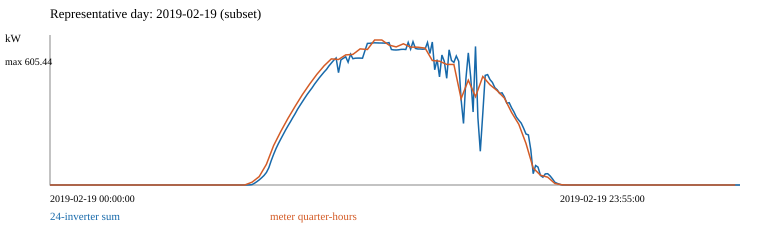

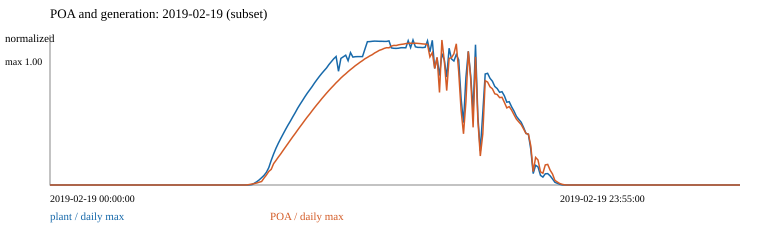

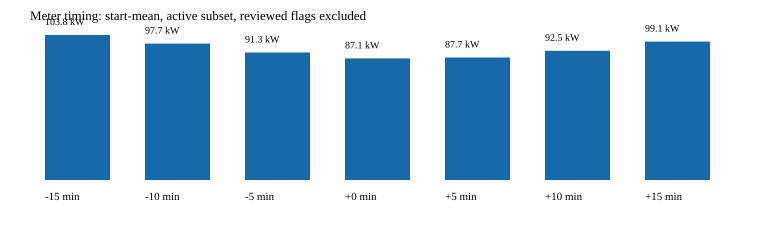

In [11]:
def line_svg(series_list,title,ylabel):
    width,height=760,230
    all_values=np.concatenate([s.dropna().to_numpy() for _,s in series_list])
    lo=min(0,float(all_values.min())); hi=float(all_values.max()) or 1
    times=sorted(set(t for _,s in series_list for t in s.index))
    t0,t1=times[0],times[-1]
    colors=['#1769aa','#d35b26','#198754']
    body=[f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        f'<text x="50" y="18" font-size="13">{html.escape(title)}</text>',
        f'<text x="5" y="42" font-size="11">{html.escape(ylabel)}</text>',
        '<path d="M50 35 V185 H740" fill="none" stroke="#888"/>']
    for k,(label,s) in enumerate(series_list):
        # Missing values break lines; do not connect through missing samples.
        segments=[]; points=[]
        for t,v in s.items():
            if pd.isna(v):
                if points: segments.append(points); points=[]
                continue
            x=50+690*(t-t0)/(t1-t0); y=185-145*(v-lo)/(hi-lo)
            points.append(f'{x:.1f},{y:.1f}')
        if points: segments.append(points)
        for points in segments:
            body.append(f'<polyline points="{" ".join(points)}" fill="none" stroke="{colors[k]}" stroke-width="1.5"/>')
        body.append(f'<text x="{50+220*k}" y="220" fill="{colors[k]}" font-size="11">{html.escape(label)}</text>')
    body += [f'<text x="50" y="202" font-size="10">{t0}</text>',f'<text x="560" y="202" font-size="10">{t1}</text>',
        f'<text x="5" y="65" font-size="10">max {hi:.2f}</text>','</svg>']
    display(SVG(''.join(body)))

# Pick the complete day with highest joint active coverage, not a statistical sample.
joint=(plant.notna()&poa.reindex(plant.index).notna())
days=joint.groupby(joint.index.normalize()).sum()
example_day=days[days.eq(288)].index[len(days[days.eq(288)])//2] if days.eq(288).any() else days.idxmax()
window=pd.date_range(example_day,example_day+pd.Timedelta(hours=23,minutes=55),freq='5min')
line_svg([('24-inverter sum',plant.reindex(window)),('meter quarter-hours',meter.loc[(meter.index>=window[0])&(meter.index<=window[-1])])],
    f'Representative day: {example_day.date()} (subset)','kW')
p=plant.reindex(window); i=poa.reindex(window)
line_svg([('plant / daily max',p/p.max()),('POA / daily max',i/i.max())],f'POA and generation: {example_day.date()} (subset)','normalized')
shift_scores=meter_scores.query("mapping == 'start_mean' and sensitivity == 'review_flags_excluded' and subset == 'active'").sort_values('sample_shift_minutes')
bars=['<svg xmlns="http://www.w3.org/2000/svg" width="760" height="230"><rect width="100%" height="100%" fill="white"/>',
    '<text x="30" y="20" font-size="13">Meter timing: start-mean, active subset, reviewed flags excluded</text>']
maximum=shift_scores.gain_rmse_kw.max()
for j,row in enumerate(shift_scores.itertuples()):
    x=45+j*100; height=145*row.gain_rmse_kw/maximum
    bars += [f'<rect x="{x}" y="{180-height:.1f}" width="65" height="{height:.1f}" fill="#1769aa"/>',
        f'<text x="{x}" y="200" font-size="11">{row.sample_shift_minutes:+} min</text>',
        f'<text x="{x}" y="{170-height:.1f}" font-size="10">{row.gain_rmse_kw:.1f} kW</text>']
display(SVG(''.join(bars)+ '</svg>'))

## Input integrity
Verify every processed input, QC ledger, and metadata hash after the audit. No dataset output is written by this notebook.

In [12]:
assert {str(p.relative_to(ROOT)):sha256(p) for p in inputs} == input_hashes
print('PASS: all eight input hashes unchanged; no dataset outputs generated.')
print('Common span:',common_start,'to',common_end)

PASS: all eight input hashes unchanged; no dataset outputs generated.
Common span: 2017-12-01 00:00:00 to 2023-10-31 23:45:00


# Cross-Dataset Alignment Audit ? Decisions Required

### A. Established facts
- Common bounds: **2017-12-01 00:00 to 2023-10-31 23:45**. All timestamps are on their nominal grids; 175,320 exact labels intersect all four files.
- Valid power/POA: 529,952 five-minute rows (85.16% of spring-adjusted common slots). Exact all-four valid inputs: 175,185 quarter-hours (84.45% of quarter-hour slots; 28.15% of five-minute slots).
- Complete three-sample all-four periods: 154,612 start-labelled (74.54%) or 154,655 end-labelled (74.56%). These require all 24 AC-power channels, temperature/wind speed, and meter; direction adds no further loss here. Requiring every electrical channel would fail because inverter 05 DC voltage is entirely missing.
- Spring 02:xx is omitted across files. Fall 01:xx appears once, not twice; ambiguous exported rows total 84 electrical, 62 irradiance, 20 environment, 28 meter across their respective spans. Available electrical/POA/meter values there are zero. Environment additionally omits fall-day 23:xx in 2018?2022.

### B. Strong evidence / likely interpretation
- Shared **Pacific local wall-clock** behavior is supported; identical DST/export handling is not. Percentages are conditional wall-clock coverage, not resolved elapsed-time coverage.
- Meter most closely matches inverter samples **t, t+5, t+10**. Equal-support active comparison: 82,209 periods, r=0.9081, gain-adjusted RMSE=86.38 kW. The +5-minute candidate is close (87.00 kW); zero sample shift wins each yearly check. A start-labelled interpretation is favored under the stated sample-support assumption, but physical start/center/end semantics remain unproven.
- POA and inverter power favor **no offset**, including every yearly comparison. Equal-support active r=0.9469 over 240,782 rows; ?5/10/15-minute offsets perform worse.
- Environment has four identical readings in every complete valid hour; all observed changes occur on whole hours. Persistence cannot distinguish a one-hour phase shift; none is justified by this audit.

### C. Still unresolved
- Meter spike 1783.68 contrasts with inverter sum 687.612 and POA 986.2: suspicion strengthens. The 12:00 meter zero contradicts 686.787 kW inverter output; the 12:15 zero coincides with all-inverter zero, despite POA 984.5 and high neighboring power. Acquisition artifacts versus a brief shared interruption remain uncertain.
- All 77 nighttime POA flags coincide with zero inverter power; available meter context is also zero. Suspicion strengthens. Only 48/135 nighttime meter flags have strict inverter context (all zero); 29 have POA context (all zero). Their small meter baseline remains unexplained.
- Electrical corrupt-event NaNs are retained. Peer/neighbor contrasts strengthen suspicion of the four unresolved electrical extremes, especially isolated 103?105 kW readings beside zero values; no new replacements are approved.
- Eleven 1400 W/m? readings coincide with 545.671?709.662 kW plant output, weakening automatic invalidity claims. The three isolated POA spikes also coincide with inverter-power peaks, weakening a POA-only artifact explanation. A sensor ceiling and spike validity remain unresolved.
- Most long gaps are sensor-specific. The longest POA absence (2022-02-18 to 2022-03-07) has 1,624 present quarter-hour inverter totals (all zero) and meter records (1,623 zero), not absent timestamps in all files. This suggests shared operational/acquisition context without proving cause.

### D. Recommended next decisions
- Choose 5-minute modelling with an explicitly approved environment/meter mapping, or complete 15-minute aggregation with an approved sample-support convention. Use the scenario counts above; do not interpolate long gaps.
- Approve a timezone/fall-fold policy and verify environment export behavior and meter interval labels before conversion or shifting. Fall ambiguity is outside daytime generation but matters to a continuous series.
- Decide required channels, dropout policy, suspect-event treatment, and sustained-zero interpretation. Cross-context narrows the questions; it does not resolve corruption or authorize changes. No final mask or merged dataset has been created.